<a href="https://colab.research.google.com/github/balasri03/Mini_project/blob/main/Vast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
data_test = pd.read_csv("/content/VAST_test.csv")
data_train = pd.read_csv("/content/VAST_train_11k.csv")
data_val = pd.read_csv("/content/VAST_val.csv")
print(data_test.head())
print("Dataset shape:", data_test.shape)
print(data_train.head())
print("Dataset shape:", data_train.shape)
print(data_val.head())
print("Dataset shape:", data_val.shape)

                                               Tweet             Target 1  \
0  I totally agree with this premise. As a younge...        nuclear power   
1  I totally agree with this premise. As a younge...        nuclear power   
2  Who is the mayor of N.Y. to assume he has the ...    illegal immigrant   
3  Who is the mayor of N.Y. to assume he has the ...  illegal immigration   
4  Who is the mayor of N.Y. to assume he has the ...            immigrant   

  Stance 1  seen?  
0    FAVOR      0  
1    FAVOR      0  
2  AGAINST      1  
3  AGAINST      1  
4  AGAINST      1  
Dataset shape: (3006, 4)
                                               Tweet                Target 1  \
0  Regulation of corporations has been subverted ...                 company   
1  Regulation of corporations has been subverted ...              regulation   
2  Regulation of corporations has been subverted ...    corporate regulation   
3  Regulation of corporations has been subverted ...  regulation corpora

In [ ]:
from scipy.sparse import data
data_train.columns = data_train.columns.str.strip()

print("Columns:", data_train.columns)
data_val.columns = data_val.columns.str.strip()

print("Columns:", data_val.columns)
data_test.columns = data_test.columns.str.strip()

print("Columns:", data_test.columns)

Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')
Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')
Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')


In [ ]:
data_train['input_text'] = data_train['Tweet'] + " target " +data_train['Target 1']

print(data_train[['input_text']].head())
data_val['input_text'] = data_train['Tweet'] + " target " +data_val['Target 1']

print(data_val[['input_text']].head())
data_test['input_text'] = data_test['Tweet'] + " target " +data_test['Target 1']

print(data_test[['input_text']].head())

                                          input_text
0  Regulation of corporations has been subverted ...
1  Regulation of corporations has been subverted ...
2  Regulation of corporations has been subverted ...
3  Regulation of corporations has been subverted ...
4  Absolutely it's needs to be defined and regula...
                                          input_text
0  Regulation of corporations has been subverted ...
1  Regulation of corporations has been subverted ...
2  Regulation of corporations has been subverted ...
3  Regulation of corporations has been subverted ...
4  Absolutely it's needs to be defined and regula...
                                          input_text
0  I totally agree with this premise. As a younge...
1  I totally agree with this premise. As a younge...
2  Who is the mayor of N.Y. to assume he has the ...
3  Who is the mayor of N.Y. to assume he has the ...
4  Who is the mayor of N.Y. to assume he has the ...


In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
data_train['input_text'] = data_train['input_text'].apply(clean_text)
data_val['input_text'] = data_val['input_text'].apply(clean_text)
data_test['input_text'] = data_test['input_text'].apply(clean_text)

In [ ]:
print(data_train.columns)
print(data_val.columns)
print(data_test.columns)

Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')
Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')
Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')


In [ ]:
encoder = LabelEncoder()

data_train['label'] = encoder.fit_transform(data_train['Stance 1'])

print(data_train[['Stance 1','label']].head())

data_val['label'] = encoder.fit_transform(data_val['Stance 1'])

print(data_val[['Stance 1','label']].head())
data_test['label'] = encoder.fit_transform(data_test['Stance 1'])

print(data_test[['Stance 1','label']].head())

  Stance 1  label
0  AGAINST      0
1  AGAINST      0
2  AGAINST      0
3  AGAINST      0
4  AGAINST      0
  Stance 1  label
0  AGAINST      0
1  AGAINST      0
2    FAVOR      1
3  AGAINST      0
4  AGAINST      0
  Stance 1  label
0    FAVOR      1
1    FAVOR      1
2  AGAINST      0
3  AGAINST      0
4  AGAINST      0


In [ ]:
data_train['label'].value_counts()

,count
label,
0,4507
1,4302
2,2496


In [ ]:
tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(data_train['input_text'])

sequences = tokenizer.texts_to_sequences(data_train['input_text'])
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(data_val['input_text'])
sequences_val = tokenizer.texts_to_sequences(data_val['input_text'])
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(data_test['input_text'])
sequences_test = tokenizer.texts_to_sequences(data_test['input_text'])

In [ ]:
encoder = LabelEncoder()

data_train['label'] = encoder.fit_transform(data_train['Stance 1'])
data_val['label'] = encoder.transform(data_val['Stance 1'])
data_test['label'] = encoder.transform(data_test['Stance 1'])

In [ ]:
print(sequences[0])

[454, 4, 549, 48, 73, 11874, 32, 549, 214, 8, 5939, 549, 12, 14, 3123, 2, 2404, 549, 8, 12, 351, 165, 2, 1305, 2590, 12, 351, 165, 2, 11875, 5, 228, 791, 8, 46, 5231, 1, 108, 124, 29, 549, 3, 21, 11876, 308, 15, 3171, 6, 1, 333, 716, 27, 885, 7, 2, 1252, 11, 414]


In [ ]:
max_len = 100

X = pad_sequences(sequences, maxlen=max_len)

In [ ]:
X_train = pad_sequences(tokenizer.texts_to_sequences(data_train['input_text']), maxlen=max_len)
X_test  = pad_sequences(tokenizer.texts_to_sequences(data_test['input_text']), maxlen=max_len)
y_train = data_train['label']
y_test  = data_test['label']

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("Max sequence length:", max_len)

Vocabulary size: 9357
Max sequence length: 100


load glove

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-04-01 04:44:45--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-01 04:44:45--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-01 04:44:45--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [ ]:
import numpy as np

embedding_dim = 100
embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:

    for line in f:

        values = line.split()

        word = values[0]

        vector = np.asarray(values[1:], dtype='float32')

        embeddings_index[word] = vector

print("Total words in GloVe:", len(embeddings_index))

Total words in GloVe: 400000


In [ ]:
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():

    vector = embeddings_index.get(word)

    if vector is not None:

        embedding_matrix[i] = vector

In [ ]:
X = pad_sequences(
    tokenizer.texts_to_sequences(data_train['input_text']),
    maxlen=max_len
)

y = data_train['label']   # ✅ same dataset

In [ ]:
class_weights = {
    0: 1.0,
    1: 1.0,
    2: 1.3   # small boost only
}

In [ ]:
input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

lstm_layer = LSTM(128)(embedding_layer)

dense = Dense(64, activation='relu')(lstm_layer)
drop = Dropout(0.5)(dense)

output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,399 (4.05 MB)

 Trainable params: 1,061,399 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

end_train = time.time()

train_time = end_train - start_train

print("Training Time:", train_time)

Epoch 1/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4482 - loss: 1.0568
Epoch 2/20


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


354/354 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5045 - loss: 1.0155
Epoch 3/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5527 - loss: 0.9609
Epoch 4/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5951 - loss: 0.9012
Epoch 5/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6268 - loss: 0.8457
Epoch 6/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6594 - loss: 0.7859
Epoch 7/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6846 - loss: 0.7410
Epoch 8/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6969 - loss: 0.7025
Epoch 9/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7270 - loss: 0.6538
Epoch 10/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7426 - loss: 0.6145
Epoch 11/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7640 - loss: 0.5672
Epoch 12/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7786 - loss: 0.5268
Epoch 13/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc

In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1061399
Parameters (Millions): 1.061399


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [ ]:
params = model.count_params()

params_m = params / 1e6

In [ ]:
results = [] # Re-initialize the results list
results.append({
    "Model": "LSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

          Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  LSTM (GloVe)  0.439122    0.45851  0.443112  0.433123        93.364947   

   Inference Time(sec)  Parameters(M)  
0             0.595065       1.061399  


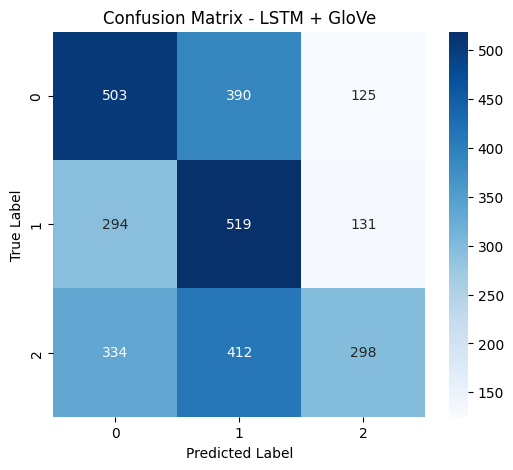

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

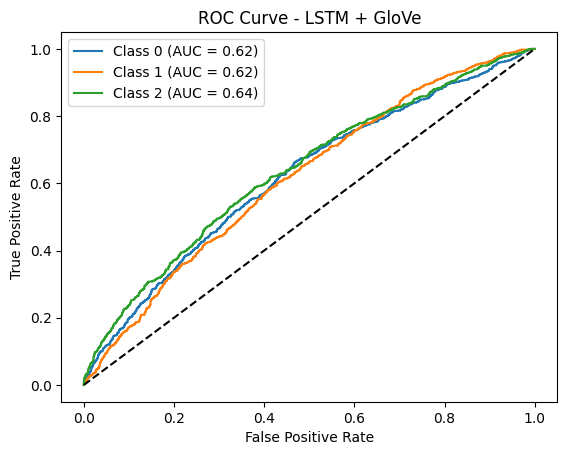

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + GloVe")

plt.legend()
plt.show()

Attention


In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
input_layer = Input(shape=(max_len,))

# Embedding layer (GloVe)
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
)(input_layer)

# 🔥 LSTM with sequences (important for attention)
lstm_layer = LSTM(128, return_sequences=True)(embedding_layer)

# 🔥 Attention
attention = Attention()([lstm_layer, lstm_layer])

# 🔥 Pooling (convert sequence → vector)
pooling = GlobalMaxPooling1D()(attention)

# Dense layers
dense1 = Dense(128, activation='relu')(pooling)
dense2 = Dense(64, activation='relu')(dense1)

drop = Dropout(0.5)(dense2)

# Output
output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 100)  │    935,700 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 100, 128)  │    117,248 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 100, 128)  │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,077,911 (4.11 MB)

 Trainable params: 1,077,911 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class_weights = {
    0: 1.1,
    1: 1.0,
    2: 1.8
}

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4812 - loss: 1.2168 - val_accuracy: 0.0000e+00 - val_loss: 1.4996
Epoch 2/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5526 - loss: 1.1744 - val_accuracy: 0.0000e+00 - val_loss: 1.5248
Epoch 3/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6038 - loss: 1.1240 - val_accuracy: 0.0000e+00 - val_loss: 1.6115
Epoch 4/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6481 - loss: 1.0556 - val_accuracy: 0.0053 - val_loss: 1.4947
Epoch 5/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6725 - loss: 0.9983 - val_accuracy: 0.0637 - val_loss: 1.7949
Epoch 6/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6830 - loss: 0.9533 - val_accuracy: 0.0513 - val_loss: 1.9265
Epoch 7/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6912 - loss: 0.9091 - val_accuracy: 0.0716 - val_loss: 1.9898
Epoch 8/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7043 - loss: 0.8685 

In [ ]:
start_inf = time.time()
pred = model.predict(X_test)
end_inf = time.time()
inference_time = end_inf - start_inf

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Total Parameters: 1077911
Parameters (Millions): 1.077911


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

params_m = params / 1e6

In [ ]:
results = []

results.append({
    "Model": "LSTM (attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  LSTM (attention)  0.407851   0.412759  0.411864  0.400429        93.364947   

   Inference Time(sec)  Parameters(M)  
0             0.600168       1.077911  


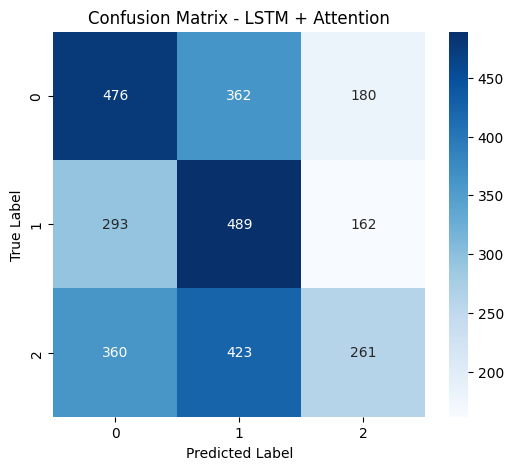

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + Attention")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

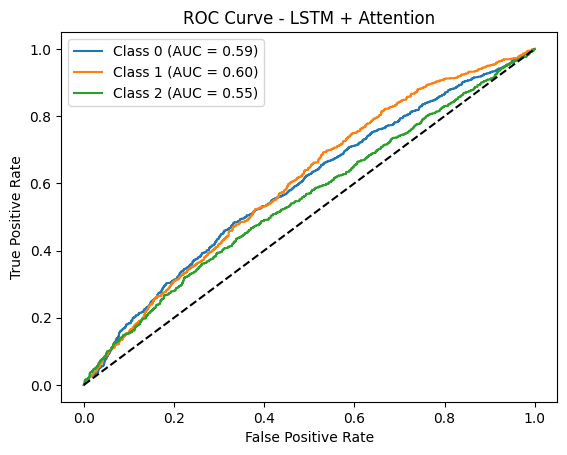

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + Attention")

plt.legend()
plt.show()

minlstm+glove

In [ ]:
import time
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# MINI LSTM (smaller units)
lstm_layer = LSTM(32)(embedding_layer)

# Dropout
dropout_layer = Dropout(0.5)(lstm_layer)

# Output layer
output_layer = Dense(3, activation='softmax')(dropout_layer)

# Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 952,823 (3.63 MB)

 Trainable params: 17,123 (66.89 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4388 - loss: 1.0633
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4770 - loss: 1.0366
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4929 - loss: 1.0190
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5046 - loss: 1.0066
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5204 - loss: 0.9895
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5292 - loss: 0.9767
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5413 - loss: 0.9663
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5483 - loss: 0.9469
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5641 - loss: 0.9322
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5749 - loss: 0.9178


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 952823
Parameters (Millions): 0.952823


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [ ]:
results = []

results.append({
    "Model": "MiniLSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
# This cell previously contained code to delete entries, which led to an empty results list.
# It has been removed to prevent accidental clearing of results. Please re-run the model
# evaluation cells to populate the 'results' list with all desired model metrics.

# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  MiniLSTM (GloVe)  0.419827   0.435903  0.427217  0.366077        31.260392   

   Inference Time(sec)  Parameters(M)  
0             0.865864       1.077911  


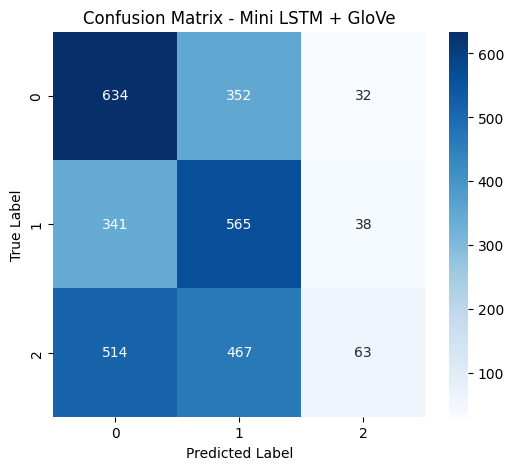

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

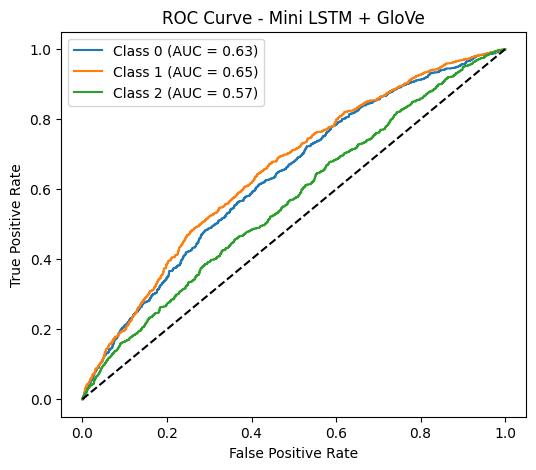

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + GloVe")

plt.legend()
plt.show()

minlstm+attention

In [ ]:
from tensorflow.keras.layers import BatchNormalization
input_layer = Input(shape=(max_len,))

# Embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

# 🔥 Mini LSTM (improved)
lstm_out = LSTM(96, return_sequences=True)(embedding_layer)

# 🔥 Attention
attention_out = Attention()([lstm_out, lstm_out])

# 🔥 Pooling
context = GlobalMaxPooling1D()(attention_out)

# Dense layers
dense1 = Dense(64, activation='relu')(context)
bn = BatchNormalization()(dense1)

drop = Dropout(0.5)(bn)

# Output
output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),   # stable LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]

)
end_train = time.time()
train_time = end_train - start_train

Epoch 1/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4236 - loss: 1.1220
Epoch 2/15


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4957 - loss: 1.0304
Epoch 3/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5336 - loss: 0.9900
Epoch 4/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5813 - loss: 0.9443
Epoch 5/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6003 - loss: 0.9081
Epoch 6/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6165 - loss: 0.8849
Epoch 7/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6200 - loss: 0.8700
Epoch 8/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6222 - loss: 0.8519
Epoch 9/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6275 - loss: 0.8402
Epoch 10/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6369 - loss: 0.8262
Epoch 11/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6456 - loss: 0.8176
Epoch 12/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6479 - loss: 0.8041
Epoch 13/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step -

In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1018007
Parameters (Millions): 1.018007


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [ ]:
results = []

results.append({
    "Model": "MiniLSTM (attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

                  Model  Accuracy  Precision    Recall  F1 score  \
0  MiniLSTM (attention)  0.395542    0.40031  0.401046  0.344717   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
0       184.332753             0.648235       1.077911  


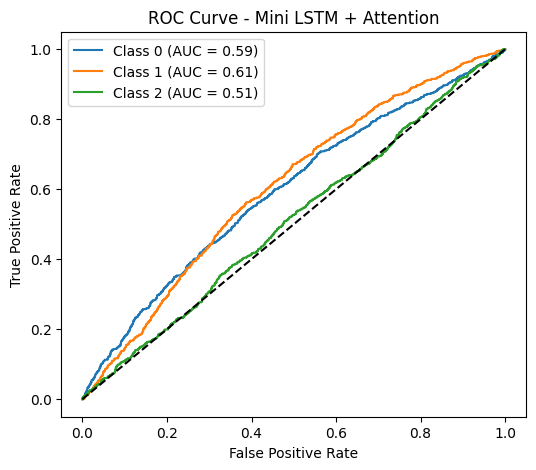

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + Attention")

plt.legend()
plt.show()

gru+glove

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# GRU layer
gru_layer = GRU(128, dropout=0.3, recurrent_dropout=0.3)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,024,407 (3.91 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 96s 263ms/step - accuracy: 0.4327 - loss: 1.0790
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


354/354 ━━━━━━━━━━━━━━━━━━━━ 93s 263ms/step - accuracy: 0.4661 - loss: 1.0457
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 139s 256ms/step - accuracy: 0.4733 - loss: 1.0372
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 93s 262ms/step - accuracy: 0.4827 - loss: 1.0248
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 91s 258ms/step - accuracy: 0.4996 - loss: 1.0147
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 91s 258ms/step - accuracy: 0.5052 - loss: 1.0023
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 92s 260ms/step - accuracy: 0.5190 - loss: 0.9867
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 141s 258ms/step - accuracy: 0.5371 - loss: 0.9675
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 92s 260ms/step - accuracy: 0.5445 - loss: 0.9523
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 92s 261ms/step - accuracy: 0.5590 - loss: 0.9380


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1024407
Parameters (Millions): 1.024407


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [ ]:
results = []
results.append({
    "Model": "GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

         Model  Accuracy  Precision   Recall  F1 score  Train Time(sec)  \
0  GRU (GloVe)   0.43147   0.474289  0.44035  0.378258      1071.216609   

   Inference Time(sec)  Parameters(M)  
0             6.826993       1.024407  


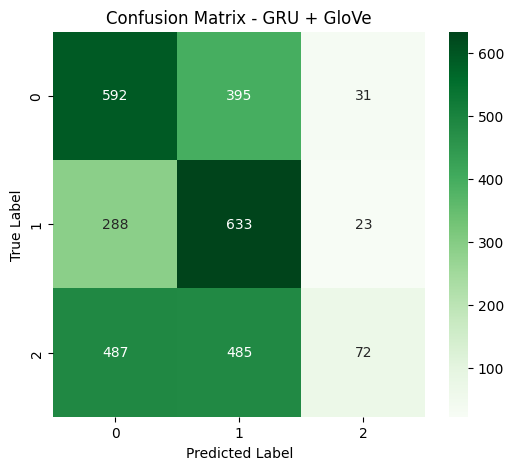

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - GRU + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

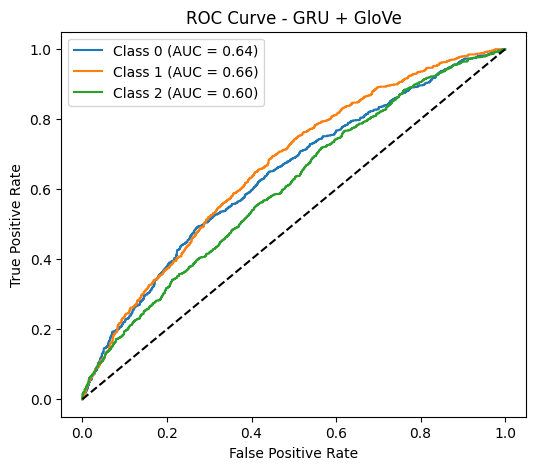

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU + GloVe")

plt.legend()
plt.show()

gru+attention

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)(input_layer)

gru_layer = GRU(128, return_sequences=True)(embedding_layer)

attention = Attention()([gru_layer, gru_layer])

pool = GlobalMaxPooling1D()(attention)

drop = Dropout(0.3)(pool)

output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 100, 100)  │    935,700 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 100, 128)  │     88,320 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 100, 128)  │          0 │ gru_1[0][0],      │
│ (Attention)         │                   │            │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ attention_3[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 3)         │        387 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,024,407 (3.91 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4499 - loss: 1.0576
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5070 - loss: 1.0107
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5466 - loss: 0.9670
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5829 - loss: 0.9267
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6072 - loss: 0.8862
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6370 - loss: 0.8447
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6525 - loss: 0.8128
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6701 - loss: 0.7820
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6860 - loss: 0.7559
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6931 - loss: 0.7372


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1024407
Parameters (Millions): 1.024407


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [ ]:
results.append({
    "Model": "GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
results_df = pd.DataFrame(results)
cleaned_gru_attention = results_df[results_df['Model'] == 'GRU (GloVe + Attention)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_gru_attention)

                     Model  Accuracy  Precision    Recall  F1 score  \
1  GRU (GloVe + Attention)  0.474052   0.502232  0.468816  0.458223   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
1        33.870374             0.601148       1.024407  


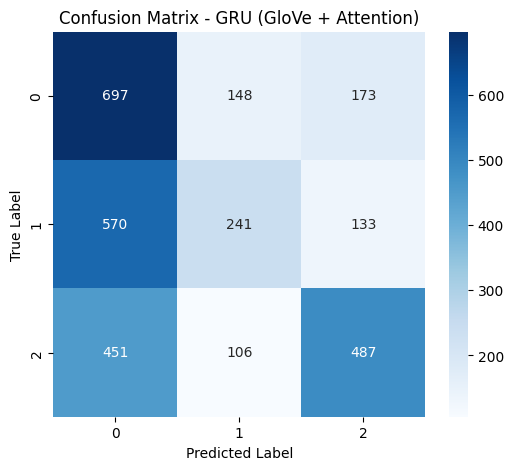

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

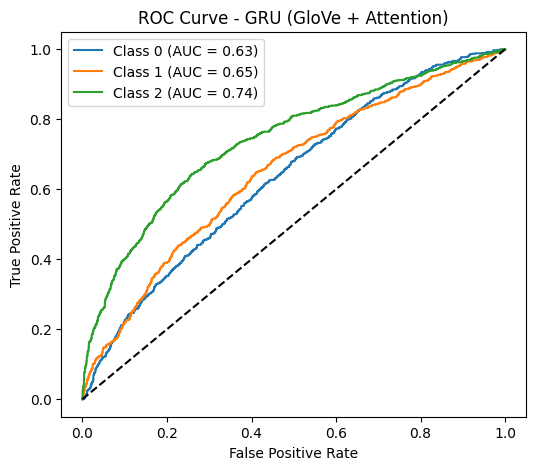

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU (GloVe + Attention)")

plt.legend()
plt.show()

mingru+glove

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 948,663 (3.62 MB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4322 - loss: 1.0737
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4733 - loss: 1.0364
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4960 - loss: 1.0132
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5122 - loss: 0.9966
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5244 - loss: 0.9804
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5394 - loss: 0.9656
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5489 - loss: 0.9483
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5677 - loss: 0.9299
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5853 - loss: 0.9084
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5973 - loss: 0.8849


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 948663
Parameters (Millions): 0.948663


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [ ]:
results.append({
    "Model": "Mini GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
results_df = pd.DataFrame(results)
cleaned_mini_gru_glove = results_df[results_df['Model'] == 'Mini GRU (GloVe)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_mini_gru_glove)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
2  Mini GRU (GloVe)  0.423819   0.448412  0.431204  0.388209        28.670976   

   Inference Time(sec)  Parameters(M)  
2             0.521522       0.948663  


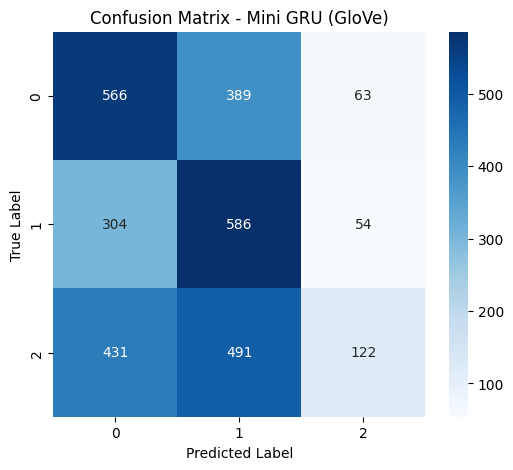

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini GRU (GloVe)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

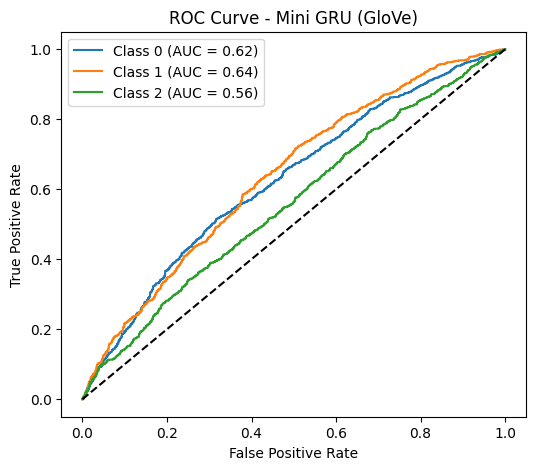

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe)")

plt.legend()
plt.show()

mingru +attention

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32, return_sequences=True)(embedding_layer)

# Attention
attention = Attention()([gru_layer, gru_layer])

# Pooling
pool = GlobalMaxPooling1D()(attention)

# Dropout
drop = Dropout(0.3)(pool)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 100, 100)  │    935,700 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 100, 32)   │     12,864 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 100, 32)   │          0 │ gru_3[0][0],      │
│ (Attention)         │                   │            │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ attention_4[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 3)         │         99 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 948,663 (3.62 MB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4372 - loss: 1.0637
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4809 - loss: 1.0387
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4984 - loss: 1.0222
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5079 - loss: 1.0063
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5261 - loss: 0.9850
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5443 - loss: 0.9663
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5552 - loss: 0.9478
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5658 - loss: 0.9362
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5809 - loss: 0.9171
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5878 - loss: 0.9034


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 948663
Parameters (Millions): 0.948663


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [ ]:
results.append({
    "Model": "Mini GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
results_df = pd.DataFrame(results)
print(results_df[results_df['Model'] == 'Mini GRU (GloVe + Attention)'])

                          Model  Accuracy  Precision    Recall  F1 score  \
3  Mini GRU (GloVe + Attention)  0.397871   0.407024  0.402093   0.36271   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
3        29.758589             0.543786       0.948663  


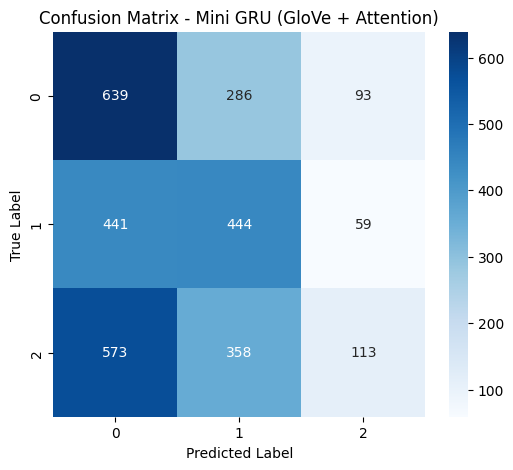

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

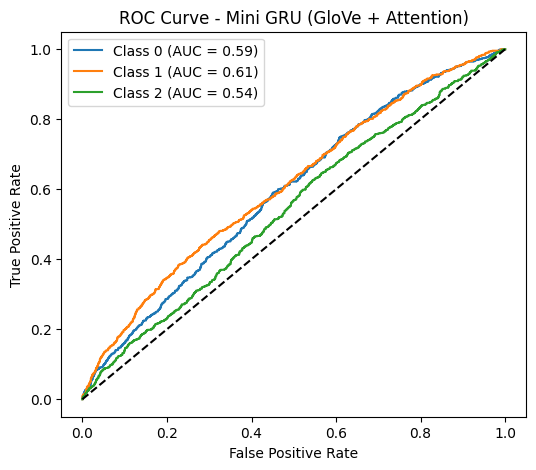

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe + Attention)")

plt.legend()
plt.show()